# Kasus 2 Transisi Fasa & Kritikalitas (T = 2.27)
## Tujuan

Simulasi ini bertujuan untuk mengimplementasikan algoritma Metropolis pada Model Ising dua dimensi untuk mengamati perilaku sistem pada temperatur rendah (T = 1.0). Pada kondisi ini diharapkan spin-spin akan cenderung berorientasi searah sehingga membentuk domain magnetik yang besar dan menghasilkan nilai magnetisasi rata-rata yang mendekati ±1.

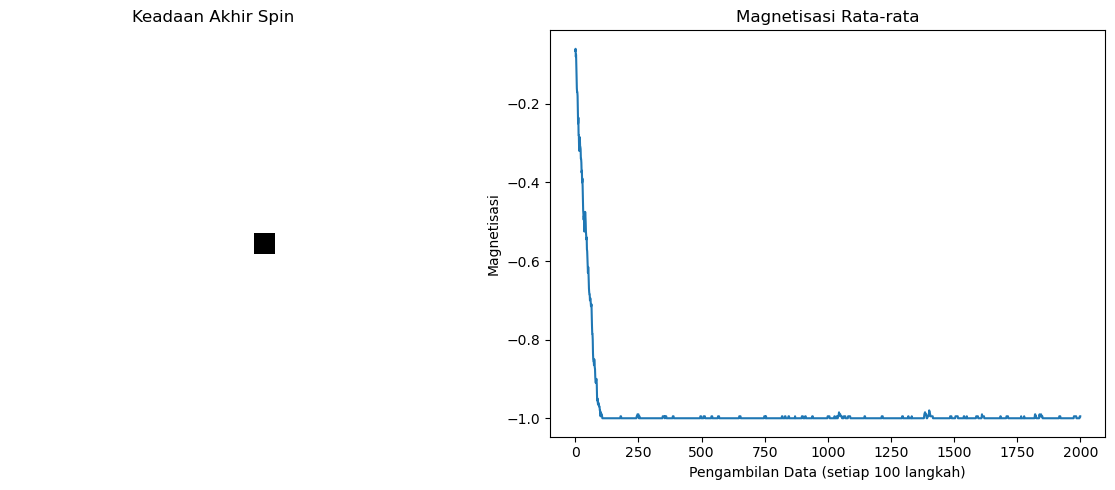

In [1]:
import numpy as np
import matplotlib.pyplot as plt
# ==============================
# PARAMETER SIMULASI
# ==============================

N = 20                 # Ukuran kisi 20 x 20
T = 1.0                # Temperatur (Fase Feromagnetik)
J = 1                  # Konstanta interaksi
MC_steps = 200000      # Jumlah Monte Carlo Step
interval = 100         # Interval penyimpanan magnetisasi
# ==============================
# HOT START
# ==============================

# Spin dipilih secara acak (-1 atau +1)

spin = np.random.choice([-1, 1], size=(N, N))
# ==============================
# FUNGSI DELTA ENERGI
# ==============================

def delta_energy(lattice, i, j):

    s = lattice[i, j]

    neighbors = (
        lattice[(i + 1) % N, j] +
        lattice[(i - 1) % N, j] +
        lattice[i, (j + 1) % N] +
        lattice[i, (j - 1) % N]
    )

    dE = 2 * J * s * neighbors

    return dE
# ==============================
# ALGORITMA METROPOLIS
# ==============================

magnetisasi = []

for step in range(MC_steps):

    # Memilih spin secara acak
    i = np.random.randint(0, N)
    j = np.random.randint(0, N)

    # Menghitung perubahan energi
    dE = delta_energy(spin, i, j)

    # Aturan Metropolis
    if dE <= 0:
        spin[i, j] *= -1

    else:
        if np.random.rand() < np.exp(-dE / T):
            spin[i, j] *= -1

    # Menyimpan magnetisasi setiap 100 langkah
    if step % interval == 0:
        M = np.sum(spin) / (N * N)
        magnetisasi.append(M)
# ==============================
# VISUALISASI
# ==============================

plt.figure(figsize=(12,5))

# Keadaan akhir spin
plt.subplot(1,2,1)
plt.imshow(spin, cmap='binary')
plt.title("Keadaan Akhir Spin")
plt.axis("off")

# Grafik magnetisasi
plt.subplot(1,2,2)
plt.plot(magnetisasi)
plt.title("Magnetisasi Rata-rata")
plt.xlabel("Pengambilan Data (setiap 100 langkah)")
plt.ylabel("Magnetisasi")

plt.tight_layout()
plt.show()

# Analisis Kasus 2 (T = 2.27)

Simulasi dilakukan pada temperatur T = 2,27 yang merupakan temperatur kritis (Tc) dari Model Ising dua dimensi. Pada kondisi ini sistem berada di batas antara fase feromagnetik dan fase paramagnetik sehingga tidak menunjukkan keteraturan sempurna maupun keadaan yang sepenuhnya acak.

Selama proses simulasi menggunakan algoritma Metropolis, spin mengalami fluktuasi yang sangat besar akibat kompetisi antara energi interaksi antar-spin dan energi termal. Domain magnetik dengan berbagai ukuran terus terbentuk dan menghilang sehingga pola spin terlihat kompleks dan menyerupai struktur fraktal.

Grafik magnetisasi memperlihatkan perubahan yang tidak stabil dengan fluktuasi yang lebih besar dibandingkan kasus suhu rendah. Nilai magnetisasi tidak bertahan di sekitar ±1 maupun 0, tetapi berubah-ubah mengikuti dinamika sistem. Hal ini menunjukkan adanya fluktuasi kritis yang menjadi ciri utama transisi fasa.

Visualisasi keadaan akhir kisi memperlihatkan campuran spin atas dan spin bawah yang membentuk domain-domain dengan ukuran yang beragam. Fenomena ini menunjukkan bahwa korelasi antar-spin masih cukup kuat, tetapi keteraturan jarak jauh mulai runtuh. Hasil simulasi sesuai dengan teori Model Ising yang menyatakan bahwa pada temperatur kritis sistem mengalami transisi dari fase feromagnetik menuju fase paramagnetik.